c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


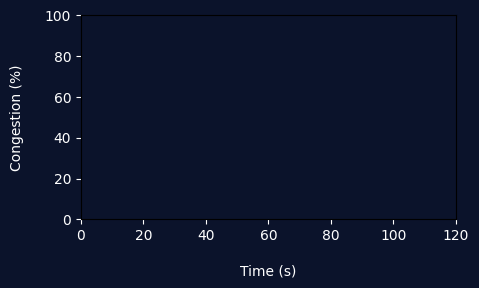

In [1]:

import subprocess
import pandas as pd
import numpy as np
import tkinter as tk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import threading
import time
from collections import deque
import joblib
import random


model = joblib.load("../models/lgbm_congestion_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

FEATURES = ['RTT', 'Length', 'loss', 'delta_time', 'rtt_std_5', 'loss_burst_5']

INTERFACE = "6"
MAX_HISTORY = 120
SMOOTHING = 0.12

# Variables globales
target_score = 10.0
current_score = 10.0
history = deque(maxlen=MAX_HISTORY)

# Capture tshark SAFE
def capture_packets():
    try:
        cmd = [
            "tshark",
            "-i", INTERFACE,
            "-a", "duration:2",
            "-f", "tcp",
            "-T", "fields",
            "-e", "frame.time_relative",
            "-e", "tcp.len"
        ]
        result = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.DEVNULL,
            text=True,
            timeout=5
        )
        rows = result.stdout.strip().split("\n")
        return [r for r in rows if "," in r]
    except:
        return []

# Fenêtre
root = tk.Tk()
root.title("AI Network Congestion Monitor")
root.geometry("900x500")
root.configure(bg="#0b132b")

# Jauge

canvas = tk.Canvas(root, width=300, height=300, bg="#0b132b", highlightthickness=0)
canvas.place(x=20, y=100)

cx, cy, r = 150, 150, 120
canvas.create_arc(cx-r, cy-r, cx+r, cy+r, start=180, extent=180, style="arc", width=10, outline="#1c2541")
needle = canvas.create_line(cx, cy, cx, cy-r+20, width=4, fill="#5bc0be")

score_text = canvas.create_text(cx, cy+40, text="0%", fill="white", font=("Segoe UI", 20, "bold"))
canvas.create_text(cx, cy+75, text="Congestion", fill="#9bbcd1")

# Graphe
fig, ax = plt.subplots(figsize=(5,3), dpi=100)
fig.patch.set_facecolor("#0b132b")
ax.set_facecolor("#0b132b")
line, = ax.plot([], [], color="#5bc0be", linewidth=2)
ax.set_ylim(0, 100)
ax.set_xlim(0, MAX_HISTORY)
ax.tick_params(colors="white")
ax.set_xlabel("Time (s)", color="white",labelpad=15)       # Nom de l'axe des abscisses
ax.set_ylabel("Congestion (%)", color="white", labelpad=15)  # Nom de l'axe des ordonnées

canvas_plot = FigureCanvasTkAgg(fig, master=root)
canvas_plot.get_tk_widget().place(x=360, y=130)
fig.subplots_adjust(bottom=0.2, left=0.15)
# UI updates
def update_needle():
    global current_score
    current_score += (target_score - current_score) * SMOOTHING

    angle = np.deg2rad(180 - current_score * 1.8)
    x = cx + (r-20) * np.cos(angle)
    y = cy - (r-20) * np.sin(angle)

    canvas.coords(needle, cx, cy, x, y)
    canvas.itemconfig(score_text, text=f"{int(current_score)}%")
    root.after(40, update_needle)

def update_graph():
    y = list(history)
    x = list(range(len(y)))
    line.set_data(x, y)
    canvas_plot.draw_idle()
    root.after(200, update_graph)

# THREAD IA (SAFE)
def prediction_loop():
    global target_score

    while True:
        rows = capture_packets()

        #  FALLBACK si tshark ne renvoie rien
        if len(rows) < 3:
            target_score += random.uniform(-3, 5)
            target_score = np.clip(target_score, 5, 35)
            history.append(target_score)
            time.sleep(0.7)
            continue

        data = []
        prev_t = None
        rtt_window = deque(maxlen=5)
        loss_window = deque(maxlen=5)

        for r in rows:
            t, length = r.split(",")
            t = float(t)
            length = float(length) if length else 0

            delta = 0.01 if prev_t is None else max(t - prev_t, 0.001)
            prev_t = t

            rtt = delta * 150 + random.uniform(3, 8)
            loss = 1 if random.random() < 0.05 else 0

            rtt_window.append(rtt)
            loss_window.append(loss)

            data.append([
                rtt,
                length,
                loss,
                delta,
                np.std(rtt_window),
                sum(loss_window)
            ])

        df = pd.DataFrame(data, columns=FEATURES)
        X_scaled = scaler.transform(df)
        proba = model.predict_proba(X_scaled)[-1]

        score = proba[0]*20 + proba[1]*55 + proba[2]*90
        target_score = float(np.clip(score, 0, 100))
        history.append(target_score)
        time.sleep(0.7)

# Lancement
threading.Thread(target=prediction_loop, daemon=True).start()
update_needle()
update_graph()
root.mainloop()
